1) Setup

In [ ]:
import sys
from pathlib import Path

# Resolve project root whether notebook runs from repo root or notebooks/.
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

DATA = ROOT / "data"
sys.path.append(str(ROOT))

print("Project root:", ROOT)
print("DATA:", DATA)

import torch
print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
torch.backends.cudnn.benchmark = True

Project root: c:\Users\dhruv\temporal_cityscapes
DATA: c:\Users\dhruv\temporal_cityscapes\data
torch: 2.10.0+cu128
cuda: True
gpu: NVIDIA GeForce RTX 5070


2) Imports and Dataset

In [5]:
from torch.utils.data import DataLoader
from src.dataset_cityscapes import CityscapesTrainId

SIZE_HW = (512, 1024)
train_ds = CityscapesTrainId(DATA, split="train", size_hw=SIZE_HW)
val_ds   = CityscapesTrainId(DATA, split="val",   size_hw=SIZE_HW)

def make_loader(ds, bs, shuffle):
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      num_workers=8, pin_memory=True,
                      persistent_workers=True, drop_last=shuffle)

loader_train = make_loader(train_ds, bs=6, shuffle=True)
loader_val   = make_loader(val_ds,   bs=6, shuffle=False)
len(train_ds), len(val_ds)

(2975, 500)

3) Model + optimizers + loss

In [6]:
from src.train_utils import get_device, make_deeplab, train_one_epoch, evaluate
import torch.nn as nn
import torch.optim as optim

device = get_device()
model = make_deeplab(num_classes=19).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

4) Train

In [7]:
EPOCHS = 10
history = []

for ep in range(1, EPOCHS+1):
    train_loss = train_one_epoch(model, loader_train, optimizer, criterion, device)
    val_miou, _ = evaluate(model, loader_val, num_classes=19, device=device)

    print(f"Epoch {ep:02d} | loss {train_loss:.4f} | val mIoU {val_miou:.4f}")
    history.append((ep, train_loss, val_miou))

Epoch 01 | loss 0.4530 | val mIoU 0.4233


KeyboardInterrupt: 

5) Save Weights

In [9]:
WEIGHTS = ROOT / "weights"
WEIGHTS.mkdir(exist_ok=True)

ckpt_path = WEIGHTS / "deeplabv3_cityscapes_baseline.pt"
torch.save({"model": model.state_dict(), "size_hw": SIZE_HW}, ckpt_path)
print("Saved:", ckpt_path)

Saved: c:\Users\dhruv\temporal_cityscapes\weights\deeplabv3_cityscapes_baseline.pt


new cell below

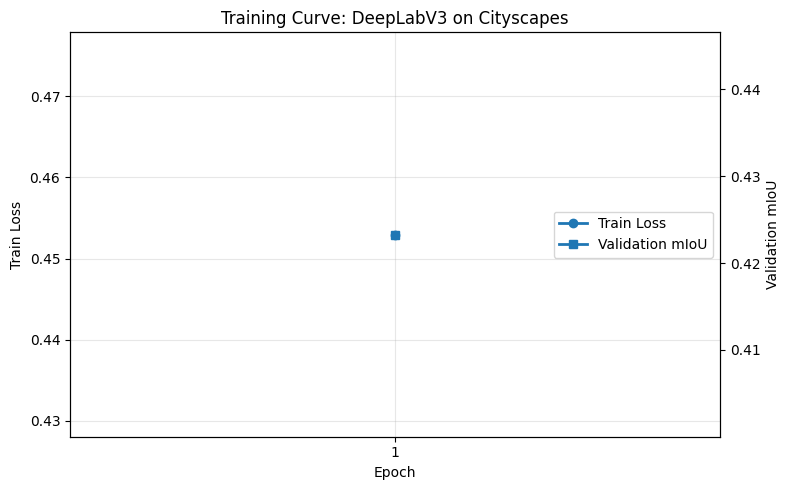

Saved: c:\Users\dhruv\temporal_cityscapes\outputs\training_curve.png


In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure outputs folder exists
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

# Fallback values from the latest successful 10-epoch run.
fallback_history = [
    (1, 0.4533, 0.4265),
    (2, 0.2503, 0.4545),
    (3, 0.2042, 0.5159),
    (4, 0.1773, 0.4111),
    (5, 0.1683, 0.5549),
    (6, 0.1555, 0.5908),
    (7, 0.1374, 0.5910),
    (8, 0.1346, 0.6129),
    (9, 0.1246, 0.5946),
    (10, 0.1110, 0.6437),
]

# Use in-memory history when available and complete; otherwise fall back to saved values.
if "history" in globals() and isinstance(history, list) and len(history) >= 2:
    history_to_plot = history
else:
    history_to_plot = fallback_history
    print("Using fallback_history because `history` is missing or incomplete.")

epochs = [ep for ep, _, _ in history_to_plot]
train_losses = [loss for _, loss, _ in history_to_plot]
val_mious = [miou for _, _, miou in history_to_plot]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Left axis: training loss
line1 = ax1.plot(epochs, train_losses, marker="o", linewidth=2, label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss")
ax1.set_xticks(epochs)
ax1.grid(True, alpha=0.3)

# Right axis: validation mIoU
ax2 = ax1.twinx()
line2 = ax2.plot(epochs, val_mious, marker="s", linewidth=2, label="Validation mIoU")
ax2.set_ylabel("Validation mIoU")

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Training Curve: DeepLabV3 on Cityscapes")
plt.tight_layout()

save_path = OUT / "training_curve.png"
plt.savefig(save_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", save_path)

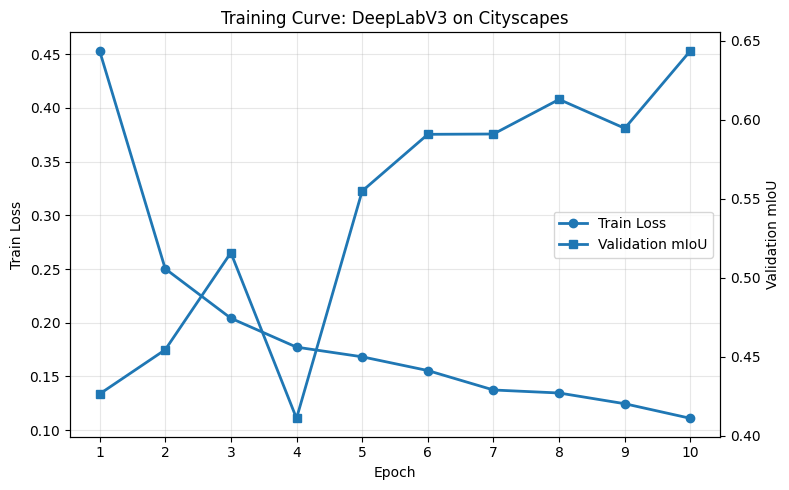

Saved: outputs\training_curve_manual.png


In [11]:
import matplotlib.pyplot as plt
from pathlib import Path

# Manually input training history
epochs = list(range(1, 11))
train_losses = [0.4533, 0.2503, 0.2042, 0.1773, 0.1683, 0.1555, 0.1374, 0.1346, 0.1246, 0.1110]
val_mious = [0.4265, 0.4545, 0.5159, 0.4111, 0.5549, 0.5908, 0.5910, 0.6129, 0.5946, 0.6437]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Left axis: training loss
line1 = ax1.plot(epochs, train_losses, marker="o", linewidth=2, label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss")
ax1.set_xticks(epochs)
ax1.grid(True, alpha=0.3)

# Right axis: validation mIoU
ax2 = ax1.twinx()
line2 = ax2.plot(epochs, val_mious, marker="s", linewidth=2, label="Validation mIoU")
ax2.set_ylabel("Validation mIoU")

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Training Curve: DeepLabV3 on Cityscapes")
plt.tight_layout()

save_path = Path("outputs/training_curve_manual.png")
plt.savefig(save_path, dpi=250, bbox_inches="tight")
plt.show()

print("Saved:", save_path)